In [ ]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process
from JR_test_scripts.escape.escape_utils import load_homing
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods
import matplotlib.gridspec as gridspec
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar
from behave_analysis.visualize.behaviour.behavioral_stats import hsv_hdir_colormap
from JR_test_scripts.FigureSaver import Figure_Saver

import os
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
from loguru import logger
import dill as pickle
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore
import matplotlib.patches as patches
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
"""Load the data"""
exp = JAL6_flip4_21mar
session_name = "JAL6_flip4_21mar"
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
explore_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
homie_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
save_path = make_directory("Z:/Jasmine_Laurence/summary_plots/Cosyne/")
tuning_data = '_25bins' # '' or '_50bins' or '_25bins
cond_colors = ['#228B22','#FF8C00','#008B8B']
homing_color = '#6A0DAD'
escape_color = '#E63946'

In [19]:
"""Load a session you want to plot"""

# 1. load in explore tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
saving_file = explore_path + exp_nickname + '_Tuning' + tuning_data + '.npz'
data = np.load(saving_file)
fr_full_exp = data['fr_full']
y_full_exp = data['y_fitted_full']
# identify cells that are sig tuned to distance to shelter in exploration
exp_sig_dist = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)

# 2. load in homing/escape tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
saving_file = homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz'
data = np.load(saving_file)
fr_full = data['fr_full']
y_full = data['y_fitted_full']
# identify cells that are sig tuned to %escape in homing/escape
sig_escape = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)

# load in residuals data
saving_file = homie_path + exp_nickname + '_ResidualsTuning' + tuning_data + '.npz'
data = np.load(saving_file)
fr_real_exp_res = data['fr_real_exp']
y_real_exp_res = data['y_fitted_real_exp']
# ifnd cells whose residual tuning to %escape - distance to shelter in exploration is significant
sig_res = data['params_real_exp'][:,:,0] > np.nanpercentile(data['params_shifts_exp_res'][:,:,:,0], 95, axis = 0)

In [ ]:
"""Plot the tuning to % escape from the real data and the predictions made using the tuning to % escape and dist to shelter in exploration"""

cond = 1
matplotlib.rcParams['font.size'] = 10

for idx in range(fr_full.shape[1]):

    # get the max firing rate for the neuron for all three plots
    max_fr = np.nanmax([np.nanmax(fr_full[cond,idx,:]), np.nanmax(fr_full_exp[cond,idx,:]), np.nanmax(fr_real_exp_res[cond,idx,:])])

    # is the tuning of the residual from shelt distance in exploration significant?
    sig = data['params_real_exp'][idx,cond,0] > np.nanpercentile(data['params_shifts_exp_res'][:,idx,cond,0], 95, axis = 0)
    label_shelter= 'Residual from shelter dist. tuning'
    if sig:
        label_shelter = label_shelter + ' is sig.'

    fig, axs = plt.subplots(1, 3, figsize = (10, 5))
    axs[0].plot(fr_full[cond,idx,:], color = 'k', linewidth = 1)
    axs[0].plot(y_full[cond,idx,:], '--', color = cond_colors[cond], linewidth = 2)
    axs[0].set_xlabel(r'% route')
    if sig_escape[idx,cond]:
        axs[0].set_title('Sig. tuned to \n' +  r'% escape')
    else:
        axs[0].set_title('Not sig. tuned to \n' +  r'% escape')
    axs[0].set_xticks([0, (fr_full.shape[2])/2, fr_full.shape[2]])
    axs[0].set_xticklabels(['0', '50', '100'])

    axs[1].plot(fr_full_exp[cond,idx,:], color = 'k', linewidth = 1)
    axs[1].plot(y_full_exp[cond,idx,:], '--', color = cond_colors[cond], linewidth = 2)
    axs[1].set_xlabel('Distance to shelter (cm) \n during exploration')
    if exp_sig_dist[idx,cond]:
        axs[1].set_title('Sig. tuned to \n' +  r'shelter dist.')
    else:
        axs[1].set_title('Not sig. tuned to \n' +  r'shelter dist.')
    axs[2].set_xticks([0, (fr_full.shape[2])/2, fr_full.shape[2]])
    axs[2].set_xticklabels(['0', '50', '100'])

    axs[2].plot(fr_real_exp_res[cond,idx,:], color = 'k', linewidth = 1)
    axs[2].plot(y_real_exp_res[cond,idx,:], '--', color = cond_colors[cond], linewidth = 2)
    axs[2].set_xlabel(r'% route')
    if sig_res[idx,cond]:
        axs[2].set_title('Sig. tuned to \n' +  r'% escape in residual')
    else:
        axs[2].set_title('Not sig. tuned to \n' +  r'% escape in residual')
    axs[2].set_xticks([0, (fr_full.shape[2])/2, fr_full.shape[2]])
    axs[2].set_xticklabels(['0', '50', '100'])

    for ax in axs:
        ax.set_ylabel('Firing Rate (Hz)')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_ylim([0, max_fr])

    plt.tight_layout()

    nickname = exp.nick_name + '_' + exp.experiment_date
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'residual_tuning'
    path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/" + nickname + "/" + exp_nickname)
    fig.savefig(path + "\\" + f'Neuron_{idx}_residual_tuning_escape.png')
    plt.clf()
    plt.close("all")

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_33168\421740560.py:54: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, max_fr])
C:\Users\Jasmine\AppData\Local\Temp\ipykernel_33168\421740560.py:54: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, max_fr])
C:\Users\Jasmine\AppData\Local\Temp\ipykernel_33168\421740560.py:54: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, max_fr])
C:\Users\Jasmine\AppData\Local\Temp\ipykernel_33168\421740560.py:54: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, max_fr])
C:\Users\Jasmine\AppData\Local\Temp\ipykernel_33168\421740560.py:54: UserWarning: Attempting to set identical low and high ylims makes transformation si

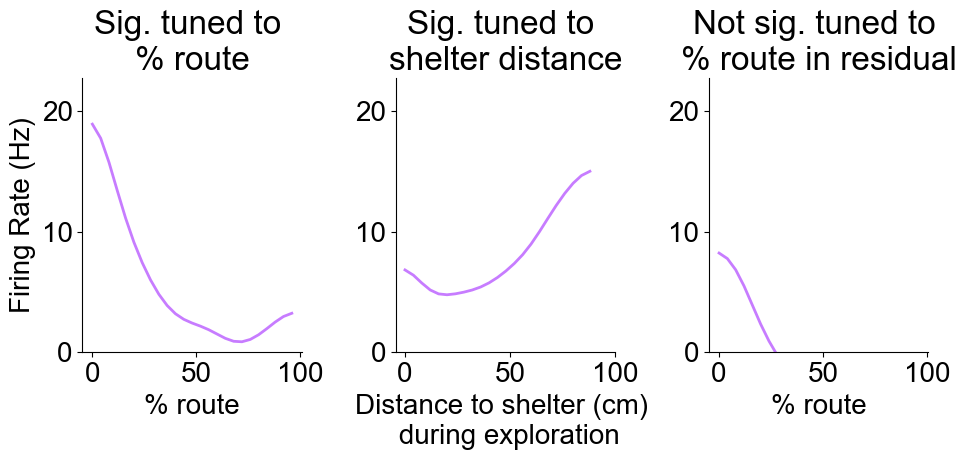

In [33]:
"""Plot the tuning to % escape from the real data and the predictions made using the tuning to % escape and dist to shelter in exploration"""

idx = 85 # 93 still tuned to escape, 85 not tuned to escape in residual
colors = [
    "#4363d8",  # Medium blue - different from your blues
    "#C77CFF",   # Light purple - distinct from your darker purple
]
color = colors[1] # 0 is for tuned to % escape, 1 is for not tuned to % escape in residual
cond = 1
matplotlib.rcParams['font.size'] = 20

# get the max firing rate for the neuron for all three plots
max_fr = np.nanmax([np.nanmax(fr_full[cond,idx,:]), np.nanmax(fr_full_exp[cond,idx,:]), np.nanmax(fr_real_exp_res[cond,idx,:])])

# is the tuning of the residual from shelt distance in exploration significant?
sig = data['params_real_exp'][idx,cond,0] > np.nanpercentile(data['params_shifts_exp_res'][:,idx,cond,0], 95, axis = 0)
label_shelter= 'Residual from shelter dist. tuning'
if sig:
    label_shelter = label_shelter + ' is sig.'

fig, axs = plt.subplots(1, 3, figsize = (10, 5))
axs[0].plot(y_full[cond,idx,:], color = color, linewidth = 2)
axs[0].set_xlabel(r'% route')
if sig_escape[idx,cond]:
    axs[0].set_title('Sig. tuned to \n' +  r'% route')
else:
    axs[0].set_title('Not sig. tuned to \n' +  r'% route')
axs[0].set_xticks([0, (fr_full.shape[2])/2, fr_full.shape[2]])
axs[0].set_xticklabels(['0', '50', '100'])

axs[1].plot(y_full_exp[cond,idx,:], color = color, linewidth = 2)
axs[1].set_xlabel('Distance to shelter (cm) \n during exploration')
if exp_sig_dist[idx,cond]:
    axs[1].set_title('Sig. tuned to \n' +  r'shelter distance')
else:
    axs[1].set_title('Not sig. tuned to \n' +  r'shelter dist.')
axs[1].set_xticks([0, (fr_full.shape[2])/2, fr_full.shape[2]])
axs[1].set_xticklabels(['0', '50', '100'])

axs[2].plot(y_real_exp_res[cond,idx,:], color = color, linewidth = 2)
axs[2].set_xlabel(r'% route')
if sig_res[idx,cond]:
    axs[2].set_title('Sig. tuned to \n' +  r'% route in residual')
else:
    axs[2].set_title('Not sig. tuned to \n' +  r'% route in residual')
axs[2].set_xticks([0, (fr_full.shape[2])/2, fr_full.shape[2]])
axs[2].set_xticklabels(['0', '50', '100'])

axs[0].set_ylabel('Firing Rate (Hz)')
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim([0, max_fr])

plt.tight_layout()

figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite = True)
figure_saver.save(fig, name_file=session_name + '_ResidualTuning_Neuron' + str(idx) + '_' + c_names[cond])
    